In [1]:
from xcube.core.store import new_data_store
from xcube.core.gridmapping import GridMapping
from xcube.core.geom import mask_dataset_by_geometry

In [2]:
%load_ext autoreload
%autoreload 2

### Land Cover

In [3]:
cci_ds = new_data_store("cciodp")

In [4]:
cci_ds.list_data_ids()

['esacci.GHG.satellite-orbit-frequency.L2.CH4.TROPOMI.Sentinel-5P.WFMD.v1-8.201711-202406',
 'esacci.AEROSOL.5-days.L3C.AEX.GOMOS.Envisat.AERGOM.3-00.r1',
 'esacci.AEROSOL.climatology.L3.AAI.multi-sensor.multi-platform.MSAAI.1-7.r1',
 'esacci.AEROSOL.day.L3.AAI.multi-sensor.multi-platform.MSAAI.1-7.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.AATSR.Envisat.ADV.2-31.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.AATSR.Envisat.ORAC.04-01-.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.AATSR.Envisat.ORAC.04-01_seg-.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.AATSR.Envisat.SU.4-3.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.ATSR-2.ERS-2.ADV.2-31.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.ATSR-2.ERS-2.ORAC.04-01-.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.ATSR-2.ERS-2.ORAC.04-01_seg-.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.ATSR-2.ERS-2.SU.4-3.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.multi-sensor.multi-platform.AATSR-ENVISAT-ENS_DAILY.v2-6.r1',
 'esacci.AEROSOL.day.L3C.AER_PRODUCTS.multi-sensor.mult

In [5]:
cci_ds.describe_data("esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1")

In [6]:
cci_ds.get_open_data_params_schema("esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1")

In [7]:
bbox = [-31, 27, 40, 81]

In [8]:
time_range = ["2015-01-01", "2015-12-31"]

In [9]:
lc_cci = cci_ds.open_data(
    "esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1", 
    bbox=bbox, 
    time_range=time_range,
)

In [10]:
lc_cci

<xarray.Dataset> Size: 10GB
Dimensions:              (time: 1, lat: 19440, lon: 25560, bnds: 2)
Coordinates:
  * lat                  (lat) float32 78kB 81.0 81.0 80.99 ... 27.01 27.0 27.0
  * lon                  (lon) float32 102kB -31.0 -31.0 -30.99 ... 40.0 40.0
  * time                 (time) datetime64[ns] 8B 2015-07-02T12:00:00
    time_bnds            (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    change_count         (time, lat, lon) float32 2GB dask.array<chunksize=(1, 1944, 2130), meta=np.ndarray>
    crs                  float64 8B ...
    current_pixel_state  (time, lat, lon) float32 2GB dask.array<chunksize=(1, 1944, 2130), meta=np.ndarray>
    lccs_class           (time, lat, lon) float32 2GB dask.array<chunksize=(1, 1944, 2130), meta=np.ndarray>
    observation_count    (time, lat, lon) float32 2GB dask.array<chunksize=(1, 1944, 2130), meta=np.ndarray>
    processed_flag       (time, lat, lon) float32 2GB dask.array<chunksize=(1, 1944, 2130), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform...
    date_created:            2025-09-02T17:48:07.783411
    processing_level:        L4
    time_coverage_start:     2015-01-01T00:00:00
    time_coverage_end:       2016-01-01T00:00:00
    time_coverage_duration:  P365DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

CPU times: total: 12.8 s
Wall time: 56.6 s


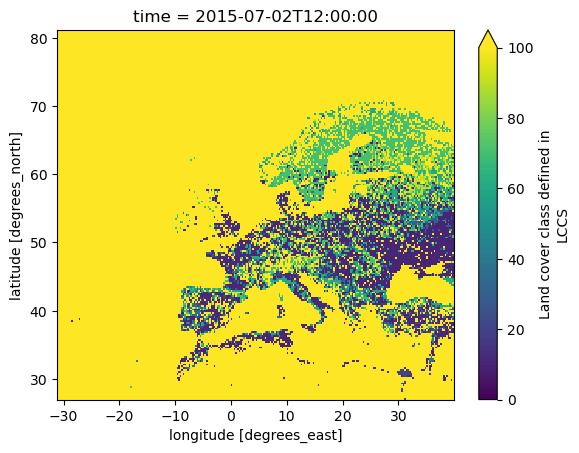

In [11]:
%%time
downsampled_cube = lc_cci.lccs_class.isel(
    lat=slice(None, None, 100),
    lon=slice(None, None, 100),
)
downsampled_cube.plot(vmin=0, vmax=100)

## The cells below use LC from S3 data cube prepared by BC (will be used later. Skip for now!)

In [12]:
store_lccs=new_data_store("s3", root="deep-esdl-public")
mlds_lc = store_lccs.open_data("LC-1x2025x2025-2.0.0.levels")
lc = mlds_lc.base_dataset

FsMultiLevelDatasetError: Failed to open dataset PurePosixPath('deep-esdl-public/LC-1x2025x2025-2.0.0.levels/0.zarr'): group not found at path ''

In [ ]:
file_store = new_data_store("file", root="input_sources")

In [ ]:
file_store.write_data(lc, "LC-1x2025x2025-2.0.0.zarr")

In [ ]:
landcover = lc.sel(time="2020-01-01")
landcover

In [ ]:
lc_gm = GridMapping.from_dataset(landcover)
lc_gm

In [ ]:
%%time
downsampled_cube = landcover.lccs_class.isel(
    lat=slice(None, None, 100),
    lon=slice(None, None, 100),
)
downsampled_cube.plot(vmin=0, vmax=100)

## Skipping ends here!

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("ebro_data/Limite_Cuenca_Ebro84.shp")
gdf.plot()
plt.show()


In [ ]:
print(gdf.crs) 

In [ ]:
gdf.geometry

In [ ]:
masked_lc = mask_dataset_by_geometry(lc_cci, gdf.geometry[0])
masked_lc

In [ ]:
lat_range = (float(masked_lc.lat.min()), float(masked_lc.lat.max()))
lon_range = (float(masked_lc.lon.min()), float(masked_lc.lon.max()))
lat_range, lon_range

In [ ]:
%%time
# downsampled_cube = masked_lc.lccs_class.isel(
#     lat=slice(None, None, 100),
#     lon=slice(None, None, 100),
# )
masked_lc.lccs_class.plot(vmin=0, vmax=100)

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

da = masked_lc["lccs_class"].isel(time=0)
plt.figure(figsize=(12, 8), dpi=600)

ax = plt.axes(projection=ccrs.PlateCarree())

da.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", cbar_kwargs={'label': da.name})

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.set_title("Ebro Landcover")

gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

plt.show()


In [ ]:
masked_lc

In [ ]:
keep_classes = [10, 11, 12, 20, 30]

In [ ]:
filtered_lc = masked_lc.lccs_class.where(masked_lc["lccs_class"].isin(keep_classes))

In [ ]:
filtered_lc

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

da = filtered_lc.isel(time=0)
plt.figure(figsize=(12, 8), dpi=600)

ax = plt.axes(projection=ccrs.PlateCarree())

da.plot.imshow(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", cbar_kwargs={'label': da.name})

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.set_title("Ebro Landcover - Only croplands")

gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

plt.show()


## ERA5 (CDS)

In [ ]:
cds_store = new_data_store("cds", normalize_names=True)

In [ ]:
data_ids = list(cds_store.get_data_ids())
data_ids

In [ ]:
data_id = (
    'reanalysis-era5-land'
)

In [ ]:
cds_store.get_open_data_params_schema(data_id)

In [ ]:
bbox = (-4.40417, 40.3375, 2.15694, 43.18194)
time_range = ("2020-01-01", "2020-01-31")
variables = ("soil_temperature_level_1", "potential_evaporation", "total_precipitation", "snowfall")
spatial_res = 0.1

In [ ]:
openers = cds_store.get_data_opener_ids()

openers

In [ ]:
cds_cube = cds_store.open_data(
    data_id,
    openers[0],
    variable_names=variables,
    bbox=bbox,
    spatial_res=spatial_res,
    time_range=("2020-01-01", "2020-01-31")
)

In [ ]:
cds_cube = cds_store.open_data(
    data_id,
    openers[0],
    variable_names=variables,
    bbox=bbox,
    spatial_res=spatial_res,
    time_range=("2020-01-01", "2020-12-31"),
)

In [ ]:
cds_cube

In [ ]:
mask = ~filtered_lc.isnull()
mask

In [ ]:
filtered_lc.plot()

In [ ]:
mask.plot()

In [ ]:
filtered_lc_resampled = filtered_lc.interp_like(cds_cube, method="nearest")
filtered_lc_resampled

In [ ]:
mask = ~filtered_lc_resampled.isnull()
mask

In [ ]:
mask.plot()

In [ ]:
masked_cds_cube = cds_cube.where(mask)
masked_cds_cube

In [ ]:
cds_gm = GridMapping.from_dataset(cds_cube)
cds_gm

In [ ]:
cds_cube.isel(time=0).stl1.plot()

In [ ]:
masked_cds_cube.isel(time=0).stl1.plot()

In [ ]:
masked_cds_cube.isel(time=0).pev.plot()

In [ ]:
masked_cds_cube.isel(time=0).tp.plot()

In [ ]:
masked_cds_cube.isel(time=0).sf.plot()

## Soil moisture (CLMS)

In [ ]:
import json
json_file_path = "credentials.json"
with open(json_file_path, "r") as j:
    credentials = json.loads(j.read())

In [ ]:
import logging
logging.getLogger("xcube.clms").setLevel(logging.DEBUG)

In [ ]:
%%time
clms_data_store = new_data_store("clms", credentials=credentials)

In [ ]:
clms_data_store.has_data("daily-surface-soil-moisture-v1.0")

In [ ]:
time_range = ("2020-01-01", "2020-01-31")
soil_moisture = clms_data_store.open_data("daily-surface-soil-moisture-v1.0", time_range=time_range)

In [ ]:
soil_moisture

In [ ]:
import pyproj
crs = pyproj.CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]]')
print(crs.to_epsg()) 

In [ ]:
sm_gm = GridMapping.from_dataset(soil_moisture)

In [ ]:
sm_gm

In [ ]:
bbox = (-4.40417, 40.3375, 2.15694, 43.18194)

In [ ]:
soil_moisture.sel(lat=slice(43.18194, 40.3375), lon=slice(-4.40417, 2.15694))

In [ ]:
%%time
soil_moisture.isel(time=0, lat=slice(None, None, 50), lon=slice(None, None, 50)).ssm.plot()